# 05 Spatial Authority: Geometry-Scoped Label Assignment
**Repo:** local_contexts_geospatial  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC  

## What This Notebook Covers
Not all datasets have uniform governance. A satellite image covering
South Dakota crosses multiple Tribal Nations, each with their own
governance authority over the portion of the data that covers their land.
A river dataset that flows through both Tribal and non-Tribal land carries
different obligations for different reaches.

This notebook introduces **spatially-scoped label assignment**, the
concept that a label's authority is tied to a specific geographic extent.

1. Building a label zone layer from Tribal boundaries
2. Assigning labels to features based on spatial intersection
3. Handling features that span multiple authority zones
4. Generating a spatial label coverage map
5. Using `assign_label_by_geometry()` for dynamic assignment during processing

In [8]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import warnings
import zipfile, io, tempfile, requests

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from shapely.geometry import LineString, Point, box
from shapely.validation import make_valid

from localcontexts.labels import TKLabel, TKMetadata, has_any_label
from localcontexts.propagation import propagate_labels, add_provenance_step
from localcontexts.spatial import (
    assign_label_by_geometry,
    assign_labels_to_geodataframe,
    build_label_zone,
    get_label_coverage_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

REAL_DIR  = REPO_ROOT/"data"/"real"
SYNTH_DIR = REPO_ROOT/"data"/"synthetic"
REAL_DIR.mkdir(parents=True, exist_ok=True)
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete.")

Imports complete.


## Load SD Tribal Boundaries and Build Label Zones

In [2]:
# Load AIANNH (from notebook 02 cache if available)
AIANNH_CACHE = REAL_DIR / "tl_2023_us_aiannh.geojson"
SD_NAMES = [
    "Pine Ridge", "Rosebud", "Standing Rock", "Cheyenne River",
    "Lower Brule", "Crow Creek", "Lake Traverse", "Flandreau",
]
COMMON_NAMES = {
    "Pine Ridge":     "Oglala Lakota", "Rosebud": "Sicangu",
    "Standing Rock":  "Standing Rock Sioux", "Cheyenne River": "Cheyenne River Sioux",
    "Lower Brule":    "Lower Brule Sioux", "Crow Creek": "Crow Creek Sioux",
    "Lake Traverse":  "Sisseton Wahpeton Oyate", "Flandreau": "Flandreau Santee Sioux",
}

if AIANNH_CACHE.exists():
    all_aiannh = gpd.read_file(AIANNH_CACHE)
else:
    print("Downloading Census TIGER AIANNH...")
    url = "https://www2.census.gov/geo/tiger/TIGER2023/AIANNH/tl_2023_us_aiannh.zip"
    r   = requests.get(url, timeout=300)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        with tempfile.TemporaryDirectory() as tmp:
            z.extractall(tmp)
            shp = next(Path(tmp).glob("*.shp"))
            all_aiannh = gpd.read_file(shp).to_crs("EPSG:4326")
    all_aiannh.to_file(AIANNH_CACHE, driver="GeoJSON")

sd_tribes = all_aiannh[all_aiannh["NAME"].isin(SD_NAMES)].copy()
sd_tribes = sd_tribes.dissolve(by="NAME", as_index=False)
sd_tribes["geometry"]    = sd_tribes.geometry.apply(make_valid)
sd_tribes["common_name"] = sd_tribes["NAME"].map(COMMON_NAMES)
print(f"SD Tribal Nations: {len(sd_tribes)}")

SD Tribal Nations: 8


In [3]:
# Define TK labels per Tribal Nation
# In production: these come from the actual community governance offices

TRIBAL_TK = {
    "Oglala Lakota":          TKLabel.NON_COMMERCIAL,
    "Rosebud Sioux":          TKLabel.NON_COMMERCIAL,
    "Standing Rock Sioux":    TKLabel.NON_COMMERCIAL,
    "Cheyenne River Sioux":   TKLabel.NOTICE,
    "Lower Brule Sioux":      TKLabel.NOTICE,
    "Crow Creek Sioux":       TKLabel.NOTICE,
    "Sisseton Wahpeton Oyate": TKLabel.NOTICE,
    "Flandreau Santee Sioux": TKLabel.NOTICE,
}

# Build label zone GeoDataFrame
label_zones = sd_tribes[["common_name", "geometry"]].copy()
label_zones["tk_label"]     = label_zones["common_name"].map(
    lambda n: TRIBAL_TK.get(n, TKLabel.NOTICE).value
)
label_zones["tk_authority"] = label_zones["common_name"].apply(
    lambda n: f"{n} Tribal Data Governance Office"
)

print("Label zones:")
print(
    label_zones[["common_name", "tk_label", "tk_authority"]]
    .to_string(index=False)
)

Label zones:
            common_name          tk_label                                          tk_authority
   Cheyenne River Sioux         TK Notice    Cheyenne River Sioux Tribal Data Governance Office
       Crow Creek Sioux         TK Notice        Crow Creek Sioux Tribal Data Governance Office
 Flandreau Santee Sioux         TK Notice  Flandreau Santee Sioux Tribal Data Governance Office
Sisseton Wahpeton Oyate         TK Notice Sisseton Wahpeton Oyate Tribal Data Governance Office
      Lower Brule Sioux         TK Notice       Lower Brule Sioux Tribal Data Governance Office
          Oglala Lakota TK Non-Commercial           Oglala Lakota Tribal Data Governance Office
                Sicangu         TK Notice                 Sicangu Tribal Data Governance Office
    Standing Rock Sioux TK Non-Commercial     Standing Rock Sioux Tribal Data Governance Office


## Assign Labels to a Point Dataset

In [4]:
# Create synthetic monitoring points scattered across SD
np.random.seed(21)
bounds = sd_tribes.total_bounds

monitoring_points = gpd.GeoDataFrame(
    [
        {
            "site_id": f"MON_{i:04d}",
            "value":   round(np.random.uniform(0.2, 0.7), 3),
            "geometry": Point(
                np.random.uniform(bounds[0], bounds[2]),
                np.random.uniform(bounds[1], bounds[3]),
            ),
        }
        for i in range(80)
    ],
    crs="EPSG:4326",
)

# Spatially assign labels
labeled = assign_labels_to_geodataframe(
    gdf           = monitoring_points,
    label_zones   = label_zones,
    label_col     = "tk_label",
    community_col = "common_name",
    how           = "intersects",
)

# Coverage report
report = get_label_coverage_report(labeled, label_col="tk_label")
print(f"\nLabel coverage: {report['label_coverage_pct']}%")
print(f"Label distribution: {report['label_distribution']}")

Spatial label assignment complete:
  19 features labeled
  61 features have no overlapping label zone

Label coverage: 23.8%
Label distribution: {'TK Non-Commercial': 10, 'TK Notice': 9}


## The Cross-Boundary Issue
A linear feature (river reach, road segment, pipeline) may cross
multiple Tribal boundaries. How do you assign a label?

In [5]:
# Synthetic river reach crossing Pine Ridge and Rosebud
# (These are not real river coordinates)
synthetic_river = gpd.GeoDataFrame(
    [
        {
            "reach_id": "R001",
            "name":     "Synthetic Creek",
            "geometry": LineString([
                (-102.8, 43.1), (-102.2, 43.2),
                (-101.5, 43.3), (-100.8, 43.4),
            ]),
        }
    ],
    crs="EPSG:4326",
)

# Check which Tribal Nations this reach intersects
river_proj = synthetic_river.to_crs("EPSG:5070")
zones_proj = label_zones.to_crs("EPSG:5070")

intersecting = gpd.sjoin(
    synthetic_river,
    label_zones[["common_name", "tk_label", "geometry"]],
    how="left", predicate="intersects",
)

print("Tribal Nations intersected by synthetic river reach:")
overlapping = intersecting.dropna(subset=["common_name"])
if overlapping.empty:
    print("  None: reach falls outside all Tribal boundaries")
    print("  (Expected with synthetic coordinates: this illustrates the pattern)")
else:
    for _, row in overlapping.iterrows():
        print(f"  {row['common_name']}: {row['tk_label']}")

print()
print("Governance principle for cross-boundary features:")
print("  The most restrictive label among all intersecting authorities applies.")
print("  If any intersecting Nation has TK Non-Commercial, the whole reach")
print("  carries that restriction, not just the portion within their boundary.")

Tribal Nations intersected by synthetic river reach:
  Oglala Lakota: TK Non-Commercial
  Sicangu: TK Notice

Governance principle for cross-boundary features:
  The most restrictive label among all intersecting authorities applies.
  If any intersecting Nation has TK Non-Commercial, the whole reach
  carries that restriction, not just the portion within their boundary.


## Dynamic Label Assignment During Processing

In [6]:
# assign_label_by_geometry() for single-geometry queries
# Useful inside a processing loop where you need to check each feature

# Example: checking a dataset footprint against the label zones
dataset_footprint = box(-102.5, 43.0, -101.5, 43.8)  

detected_label = assign_label_by_geometry(
    dataset_geometry = dataset_footprint,
    label_zones      = label_zones,
    label_col        = "tk_label",
    community_col    = "common_name",
    authority_col    = "tk_authority",
)

if detected_label:
    print("Label detected for dataset footprint:")
    for k, v in detected_label.items():
        print(f"  {k}: {v}")
    # Attach to dataset metadata
    dataset_meta = {"name": "sd_ndvi_tile", "extent": str(dataset_footprint.bounds)}
    dataset_meta = propagate_labels(detected_label, dataset_meta)
    print(f"\nLabel attached to dataset: {dataset_meta.get('tk:label')}")
else:
    print("No Tribal label zone intersects this footprint.")

Label detected for dataset footprint:
  tk:label: TK Non-Commercial
  tk:community: Oglala Lakota
  tk:authority: Oglala Lakota Tribal Data Governance Office

Label attached to dataset: TK Non-Commercial


## Spatial Authority Map

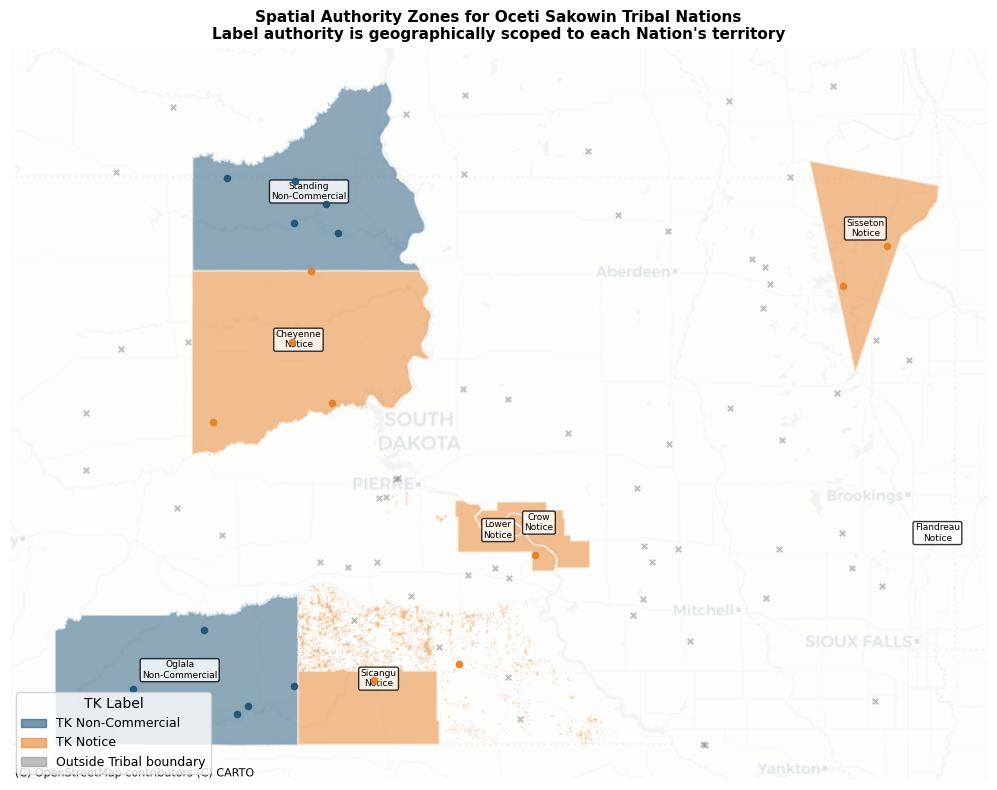

In [7]:
LABEL_COLORS = {
    TKLabel.NON_COMMERCIAL.value: "#1A5276",
    TKLabel.NOTICE.value:         "#E67E22",
    TKLabel.CULTURALLY_SENSITIVE.value: "#C0392B",
}
DEFAULT_COLOR = "#AEB6BF"

fig, ax = plt.subplots(figsize=(13, 8))

for _, zone in label_zones.iterrows():
    color = LABEL_COLORS.get(zone["tk_label"], DEFAULT_COLOR)
    gpd.GeoDataFrame([zone], crs="EPSG:4326").to_crs(3857).plot(
        ax=ax, facecolor=color, alpha=0.5,
        edgecolor="white", linewidth=1.5, zorder=2,
    )
    c = zone.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs="EPSG:4326").to_crs(3857).iloc[0]
    ax.annotate(
        f"{zone['common_name'].split()[0]}\n{zone['tk_label'].split()[-1]}",
        (c3857.x, c3857.y),
        ha="center", fontsize=6.5,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
    )

# Plot monitoring points
for label_val, color in LABEL_COLORS.items():
    pts = labeled[labeled["tk_label"] == label_val]
    if not pts.empty:
        pts.to_crs(3857).plot(
            ax=ax, color=color, markersize=20, marker="o",
            alpha=0.9, zorder=4,
        )
unlabeled_pts = labeled[labeled["tk_label"].isna()]
if not unlabeled_pts.empty:
    unlabeled_pts.to_crs(3857).plot(
        ax=ax, color="gray", markersize=15, marker="x",
        alpha=0.5, zorder=4,
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.3)
except Exception:
    pass

ax.set_axis_off()
ax.legend(
    handles=[
        mpatches.Patch(color=LABEL_COLORS[TKLabel.NON_COMMERCIAL.value],
                       alpha=0.6, label="TK Non-Commercial"),
        mpatches.Patch(color=LABEL_COLORS[TKLabel.NOTICE.value],
                       alpha=0.6, label="TK Notice"),
        mpatches.Patch(color="gray", alpha=0.5, label="Outside Tribal boundary"),
    ],
    loc="lower left", fontsize=9, title="TK Label",
)
ax.set_title(
    "Spatial Authority Zones for Oceti Sakowin Tribal Nations\n"
    "Label authority is geographically scoped to each Nation's territory",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Summary
| Function | What it does |
|---|---|
| `assign_label_by_geometry(geom, zones)` | Single geometry the first intersecting zone's label |
| `assign_labels_to_geodataframe(gdf, zones)` | Batch spatial join for an entire GeoDataFrame |
| `build_label_zone(geometry, tk_meta)` | Create a single-row label zone from a TKMetadata object |
| `get_label_coverage_report(gdf)` | Summary of labeled vs. unlabeled features |

**Governance principle:** Label authority is spatially bounded.
A Tribal Nation's label applies to data that covers their territory.
For cross-boundary features, apply the most restrictive label.

## Next Notebook
**06 CARE Validation:** Runtime governance checks that run before
data is shared, exported, or used with explicit framing of each
CARE principle.